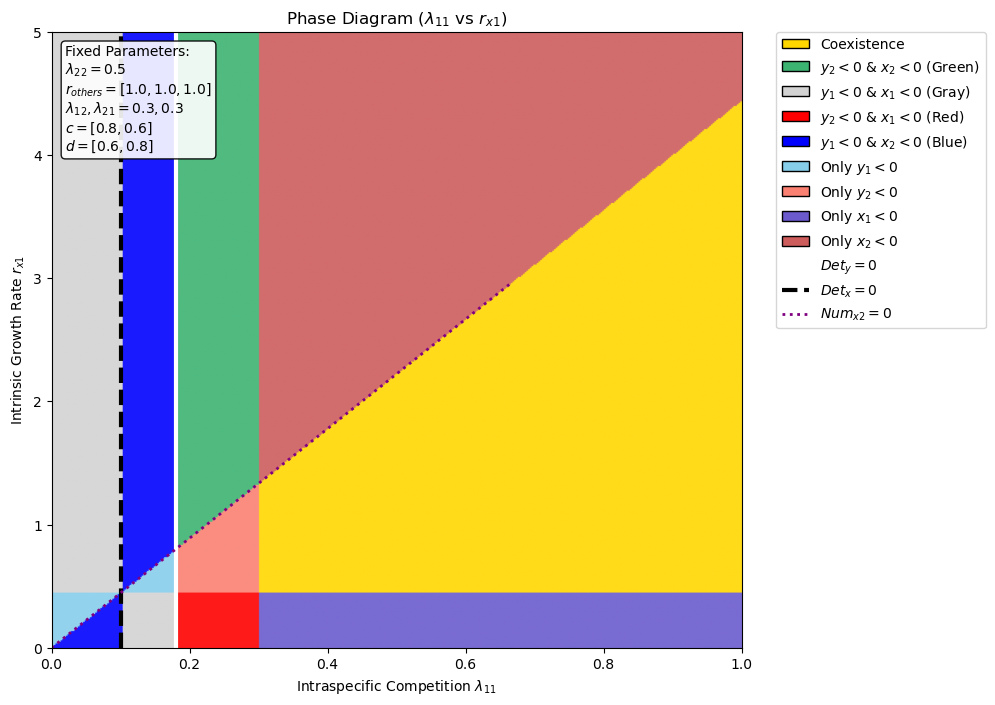

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. パラメータ設定
# r_x1 は変数になるためリストから除外、lambda_22 は固定値として定義
params_fixed = {
    'r_others': [1.0, 1.0, 1.0],    # [ry1, rx2, ry2] (rx1は変数化)
    'lambda_22': 0.5,               # 固定
    'lambda_offdiag': [0.3, 0.3],   # [lambda12, lambda21]
    'c': [0.8, 0.6],                # [c1, c2]
    'd': [0.6, 0.8]                 # [d1, d2]
}

ry1, rx2, ry2 = params_fixed['r_others']
l22 = params_fixed['lambda_22']
l12, l21 = params_fixed['lambda_offdiag']
c1, c2 = params_fixed['c']
d1, d2 = params_fixed['d']

# 2. メッシュグリッド
res = 400
# X軸: lambda11
l11_vals = np.linspace(0.001, 1.0, res)
# Y軸: rx1 (元の1.5を中心に0～3.0まで振ってみます)
rx1_vals = np.linspace(0.001, 5.0, res)

L11, RX1 = np.meshgrid(l11_vals, rx1_vals)

# 3. 計算
# ここでは固定値 l22 と、メッシュ変数 RX1, L11 を使用します

# 行列式 (分母)
# Det_x, Det_y は rx1 に依存しないため、L11 だけで値が決まります（縦縞のような変化）
Det_x = c1 * d2 * L11 * l22 - c2 * d1 * l12 * l21
Det_y = L11 * l22 - l12 * l21

# 分子
# Num_x1, Num_x2 は RX1 (Y軸) に依存します
Num_x1 = d2 * l22 * RX1 - d1 * l21 * rx2
Num_x2 = c1 * L11 * rx2 - c2 * l12 * RX1
Num_y1 = l22 * ry1 - l12 * ry2
Num_y2 = L11 * ry2 - l21 * ry1

with np.errstate(divide='ignore', invalid='ignore'):
    X1 = Num_x1 / Det_x
    X2 = Num_x2 / Det_x
    Y1 = Num_y1 / Det_y
    Y2 = Num_y2 / Det_y

# 4. 領域のカテゴリ分け
Category = np.zeros_like(X1, dtype=int)

pos_x1 = X1 > 0
pos_x2 = X2 > 0
pos_y1 = Y1 > 0
pos_y2 = Y2 > 0

# --- Step 1: 単独条件（背景） ---
Category[~pos_y1] = 2
Category[~pos_y2] = 3
Category[~pos_x1] = 4
Category[~pos_x2] = 5

# --- Step 2: 複合条件（優先度高） ---
mask_green = (~pos_y2) & (~pos_x2)
mask_gray  = (~pos_y1) & (~pos_x1)
mask_red   = (~pos_y2) & (~pos_x1)
mask_blue  = (~pos_y1) & (~pos_x2)

Category[mask_green] = 6
Category[mask_gray]  = 7
Category[mask_red]   = 8
Category[mask_blue]  = 9

# --- Step 3: 共存（最優先） ---
mask_coexist = pos_x1 & pos_x2 & pos_y1 & pos_y2
Category[mask_coexist] = 1

# 5. プロット
# （前略：計算ロジックまではそのまま）

# --- 5. プロット ---
# 凡例スペースを確保するため、少し横長にします
fig, ax = plt.subplots(figsize=(12, 8))

# カラーマップ設定
colors = [
    'white',        # 0
    'gold',         # 1: Coexist
    'skyblue',      # 2: y1<0
    'salmon',       # 3: y2<0
    'SlateBlue',    # 4: x1<0
    'IndianRed',    # 5: x2<0
    'MediumSeaGreen', # 6: Green
    'lightgray',    # 7: Gray
    'red',          # 8: Red
    'blue'          # 9: Blue
]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, 10.5, 1), cmap.N)

# 描画
im = ax.imshow(Category, extent=[0, 1.0, 0, 5.0], origin='lower',
               cmap=cmap, norm=norm, aspect='auto', alpha=0.9)

# --- 補助線の描画 ---
# 特異点 (Det = 0)
singularity_y_val = (l12 * l21) / l22
num_sing_x = c2 * d1 * l12 * l21
den_sing_x = c1 * d2 * l22
singularity_x_val = num_sing_x / den_sing_x

ax.axvline(x=singularity_y_val, color='white', linestyle='-', linewidth=3, label=r'Singularity ($Det_y = 0$)')
ax.axvline(x=singularity_x_val, color='black', linestyle='--', linewidth=3, label=r'Singularity ($Det_x = 0$)')

# Num_x2 = 0 の境界線
slope_num_x2 = (c1 * rx2) / (c2 * l12)
x_line = np.linspace(0, 1.0, 100)
y_line_num_x2 = slope_num_x2 * x_line
# 範囲外を描画しないようにNaN化
y_line_num_x2[y_line_num_x2 > 3.0] = np.nan
ax.plot(x_line, y_line_num_x2, color='purple', linestyle=':', linewidth=2, label=r'$Num_{x2}=0$ Boundary')

# --- ラベルとタイトル ---
ax.set_xlabel(r'Intraspecific Competition $\lambda_{11}$')
ax.set_ylabel(r'Intrinsic Growth Rate $r_{x1}$')
ax.set_title(r'Phase Diagram ($\lambda_{11}$ vs $r_{x1}$)')
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 5.0)

# --- パラメータ表示 ---
textstr = '\n'.join((
    r'Fixed Parameters:',
    r'$\lambda_{22} = %.1f$' % l22,
    r'$r_{others} = [%.1f, %.1f, %.1f]$' % (ry1, rx2, ry2),
    r'$\lambda_{12}, \lambda_{21} = %.1f, %.1f$' % (l12, l21),
    r'$c = [%.1f, %.1f]$' % (c1, c2),
    r'$d = [%.1f, %.1f]$' % (d1, d2)
))
props = dict(boxstyle='round', facecolor='white', alpha=0.9)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)

# --- 凡例設定 (修正ポイント) ---
legend_elements = [
    Patch(facecolor='gold', edgecolor='k', label='Coexistence'),
    Patch(facecolor='MediumSeaGreen', edgecolor='k', label='$y_2 < 0$ & $x_2 < 0$ (Green)'),
    Patch(facecolor='lightgray', edgecolor='k', label='$y_1 < 0$ & $x_1 < 0$ (Gray)'),
    Patch(facecolor='red', edgecolor='k', label='$y_2 < 0$ & $x_1 < 0$ (Red)'),
    Patch(facecolor='blue', edgecolor='k', label='$y_1 < 0$ & $x_2 < 0$ (Blue)'),
    # 単独絶滅も念のため表示
    Patch(facecolor='skyblue', edgecolor='k', label='Only $y_1 < 0$'),
    Patch(facecolor='salmon', edgecolor='k', label='Only $y_2 < 0$'),
    Patch(facecolor='SlateBlue', edgecolor='k', label='Only $x_1 < 0$'),
    Patch(facecolor='IndianRed', edgecolor='k', label='Only $x_2 < 0$'),
    
    Line2D([0], [0], color='white', lw=3, label=r'$Det_y=0$'),
    Line2D([0], [0], color='black', linestyle='--', lw=3, label=r'$Det_x=0$'),
    Line2D([0], [0], color='purple', linestyle=':', lw=2, label=r'$Num_{x2}=0$')
]

# グラフの右側(right=0.7)までしか図を描画せず、残り(0.3)を凡例用に空ける
plt.subplots_adjust(right=0.7)

# 凡例を枠外(1.05)に配置
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1.0), borderaxespad=0.)

plt.show()